In [2]:
from langchain_community.tools import ArxivQueryRun, WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper, ArxivAPIWrapper

c:\Users\mendh\Langchain-Langgraph\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [3]:
arxiv_api_wrapper = ArxivAPIWrapper(top_k_results=3,doc_content_chars_max=5000)
arxiv = ArxivQueryRun(api_wrapper = arxiv_api_wrapper)


In [4]:
print(arxiv.invoke("What is reinforcement learning"))

Published: 2026-02-12
Title: Value Bonuses using Ensemble Errors for Exploration in Reinforcement Learning
Authors: Abdul Wahab, Raksha Kumaraswamy, Martha White
Summary: Optimistic value estimates provide one mechanism for directed exploration in reinforcement learning (RL). The agent acts greedily with respect to an estimate of the value plus what can be seen as a value bonus. The value bonus can be learned by estimating a value function on reward bonuses, propagating local uncertainties around rewards. However, this approach only increases the value bonus for an action retroactively, after seeing a higher reward bonus from that state and action. Such an approach does not encourage the agent to visit a state and action for the first time. In this work, we introduce an algorithm for exploration called Value Bonuses with Ensemble errors (VBE), that maintains an ensemble of random action-value functions (RQFs). VBE uses the errors in the estimation of these RQFs to design value bonuses 

In [5]:
api_wiki = WikipediaAPIWrapper(top_k_results=3,doc_content_chars_max=5000)
wiki = WikipediaQueryRun(api_wrapper=api_wiki)
print(wiki.name)

wikipedia


In [6]:
print(wiki.invoke("What is reinforcement learning"))

Page: Reinforcement learning from human feedback
Summary: In machine learning, reinforcement learning from human feedback (RLHF) is a technique to align an intelligent agent with human preferences. It involves training a reward model to represent preferences, which can then be used to train other models through reinforcement learning.
In classical reinforcement learning, an intelligent agent's goal is to learn a function that guides its behavior, called a policy. The function is iteratively optimized to increase the reward signal derived from the agent's task performance. However, explicitly defining a reward function that accurately approximates human preferences is challenging. Therefore, RLHF seeks to train a "reward model" directly from human feedback. The reward model is first trained in a supervised manner to predict if a response to a given prompt is good (high reward) or bad (low reward) based on ranking data collected from human annotators. This model then serves as a reward f

In [7]:
from dotenv import load_dotenv
load_dotenv()

import os

os.environ["TAVILY_API_KEY"] = os.getenv("TAVILY_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

In [8]:
from langchain_community.tools.tavily_search import TavilySearchResults

tavily  = TavilySearchResults()

tavily.invoke("Preparation for AI/ML Engineer roles at MAANG (Meta, Amazon, Apple, Netflix, Google) in 2026")

C:\Users\mendh\AppData\Local\Temp\ipykernel_22260\1983817071.py:3: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily  = TavilySearchResults()


[{'title': 'Crack Amazon Meta Google Netflix or Microsoft in 2026 with ...',
  'url': 'https://www.linkedin.com/posts/zarreenshaikh_dreamjob2026-maangprep-crackmaang-activity-7408836948196261888-Ebqg',
  'content': '🚀 2025 is Almost Over – Are You Ready to Land Your Dream Job in 2026? If your goal for 2026 is to crack your dream company Amazon Meta Google Netflix Apple Microsoft , or top tech firms here’s what you NEED to do: 1️⃣️Master the Fundamentals Don’t just skim concepts understand them deeply. Algorithms, data structures, system design, and product sense are non-negotiable. 2️⃣️Build Real Projects Hiring managers love proof, not promises. Build projects, contribute to open source, or create your own app. Show impact, not just skills. 3️⃣️Mock Interviews Are Your Secret Weapon Start early. Use platforms like LeetCode, InterviewBit, or peer mock interviews. Simulate the pressure, and learn to think out loud. 4️⃣️Personal Branding = Your Invisible Resume Share your journey on Link

In [9]:
def Add(a:int,b:int)->int:
    """Function to add two int variables
    
    Args:
        a:(int):
        b:(int)
        
    Returns:
    int
    
"""
    return a+b

def Subtract(a:int,b:int)->int:
    """Function to subtract two int variables
    
    Args:
        a:(int):
        b:(int)
        
    Returns:
    int
    
"""
    return a-b

def Multiply(a:int,b:int)->int:
    """Function to Multiply two int variables
    
    Args:
        a:(int):
        b:(int)
        
    Returns:
    int
    
"""
    return a*b


In [10]:
tools = [arxiv,wiki,tavily,Add,Subtract,Multiply]

from langchain_groq import ChatGroq

llm = ChatGroq(model = "qwen/qwen3-32b")

llm_with_tools = llm.bind_tools(tools)

In [11]:
from pprint import pprint
from langchain_core.messages import AIMessage,HumanMessage
response = llm_with_tools.invoke([HumanMessage(content=f"What is the Artificial Intelligence")])

In [12]:
from typing_extensions import TypedDict
from langchain_core.messages import AnyMessage
from typing import Annotated
from langgraph.graph.message import add_messages

class State(TypedDict):
    messages:Annotated[list[AnyMessage],add_messages]

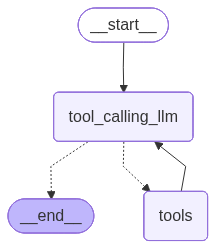

In [13]:
from IPython.display import Image,display
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode, tools_condition

def tool_calling_llm(state:State):
    return {"messages":[llm_with_tools.invoke(state["messages"])]} 


builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    tools_condition,
)

builder.add_edge("tools","tool_calling_llm")

graph = builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [14]:
messages = graph.invoke({"messages":HumanMessage(content="Attention is all you need")})

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Attention is all you need
================================== Ai Message ==================================
Tool Calls:
  arxiv (xp65f8tr6)
 Call ID: xp65f8tr6
  Args:
    query: Attention is all you need
================================= Tool Message =================================
Name: arxiv

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer in a vision transformer with a feed-forward layer applied over the patch dimension

In [15]:
messages = graph.invoke({"messages":HumanMessage(content="Latest AI news")})

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Latest AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search_results_json (g5pn2kwfc)
 Call ID: g5pn2kwfc
  Args:
    query: Latest AI news
================================= Tool Message =================================
Name: tavily_search_results_json

[{"title": "AI News | Latest News | Insights Powering AI-Driven Business Growth", "url": "https://www.artificialintelligence-news.com/", "content": "Governance, Regulation & Policy\n\nApril 13, 2026\n\n### IBM: How robust AI governance protects enterprise margins\n\nGovernance, Regulation & Policy\n\nApril 10, 2026\n\n### KPMG: Inside the AI agent playbook driving enterprise margin gains\n\nAI Business Strategy\n\nApril 1, 2026\n\n#### Industries\n\n### Trustpilot partners with AI companies as traditional search declines\n\nRetail & Logistics AI\n\nMarch 17, 2026\n\n### Agentic AI in finance s

In [16]:
messages = graph.invoke({"messages":HumanMessage(content="What is Machine Learning")})

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

What is Machine Learning
================================== Ai Message ==================================
Tool Calls:
  wikipedia (t87qf2n7a)
 Call ID: t87qf2n7a
  Args:
    query: Machine Learning
================================= Tool Message =================================
Name: wikipedia

Page: Machine learning
Summary: Machine learning (ML) is a field of study in artificial intelligence concerned with the development and study of statistical algorithms that can learn from data and generalize to unseen data, and thus perform tasks without explicit programming language instructions. Within a subdiscipline of machine learning, advances in the field of deep learning have allowed neural networks, a class of statistical algorithms, to surpass many previous machine learning approaches in performance.
Statistics and mathematical optimisation (mathematical programming) methods compose the foundations of mac

In [17]:
messages = graph.invoke({"messages":HumanMessage(content="Hi I am Vishal Mendhikar")})

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi I am Vishal Mendhikar
================================== Ai Message ==================================

Hello Vishal Mendhikar! How can I assist you today?


In [19]:
messages = graph.invoke({"messages":HumanMessage(content="Whatis2+2")})

for m in messages["messages"]:
    m.pretty_print()

================================ Human Message =================================

Whatis2+2
================================== Ai Message ==================================
Tool Calls:
  Add (ng71vvqfz)
 Call ID: ng71vvqfz
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: Add

4
================================== Ai Message ==================================

The result of 2 + 2 is **4**.
